## 과제 (low, high-> 케라스)
- 피마인디안 데이터셋 이용
- train, test 나누기
- 정규화
- 딥러닝
- train, test 정확도, f1, confusion matrix
- train 1,2 예측값

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압(mm Hg)
- SkinThickness: 팔 삼두근 뒤쪽의 피하지방 측정값(mm)
- Insulin: 혈청 인슐린(mu U/ml)
- BMI: 체질량지수(체중(kg)/(키(m))^2)
- DiabetesPedigreeFunction: 당뇨 내력 가중치 값
- Age: 나이
- Outcome: 클래스 결정 값(0또는 1)

In [51]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sb
from scikeras.wrappers import KerasClassifier, KerasRegressor # 분류 KerasClassifier , 회귀(연속값) KerasRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [52]:
df = pd.read_csv('../../data/pima-indians-diabetes.data.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [53]:
x_data = df.iloc[:,:-1]
y_data = df.iloc[:, -1]

In [54]:
x_data.shape

(768, 8)

In [56]:
y_data.shape

(768,)

---

train, test 나누기

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

--- 

정규화

In [58]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [59]:
x_train_s.shape

(614, 8)

In [60]:
y_train.shape

(614,)

--- 

딥러닝

In [61]:
myin = Input(shape=(8,)) # 입력층: Input layer
dense1 = Dense(units=32, activation='relu')    # hidden layer
dense2 = Dense(units=16, activation='relu')    # hidden layer
dense3 = Dense(units=1,  activation='sigmoid') # output layer
model = Sequential( [myin, dense1, dense2, dense3] )
model.compile(loss='binary_crossentropy', optimizer=Adam(0.01), metrics=['acc']) # acc : 정확도를 출력해줌
h = model.fit(x_train_s, y_train, epochs=500)

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7215 - loss: 0.5212   
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7866 - loss: 0.4524 
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7834 - loss: 0.4422 
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - acc: 0.7932 - loss: 0.4272
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.7964 - loss: 0.4202 
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8192 - loss: 0.4100 
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7915 - loss: 0.4158 
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7997 - loss: 0.4232 
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8062 - loss: 0.4004 
Epoch 10/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8160 - loss: 0.3862 
Epoch 11/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8274 - loss: 0.3826 
Epoch 12/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8290 - loss: 0.3684 
Epoch 13/500
20/20 ━━━

In [71]:
pred_tr = (model.predict(x_train_s) > 0.5) + 0
pred_tr

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
    

In [63]:
pred_ts = (model.predict(x_test_s) > 0.5) + 0
pred_ts

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

---

train, test 정확도, f1, confusion matrix

In [69]:
print('accuracy_score(Train)',accuracy_score(y_train, pred_tr))
print('accuracy_score(Test)',accuracy_score(y_test, pred_ts))

accuracy_score(Train) 1.0
accuracy_score(Test) 0.7207792207792207


In [70]:
print('f1_score(Train)',f1_score(y_train, pred_tr))
print('f1_score(Test)',f1_score(y_test, pred_ts))

f1_score(Train) 1.0
f1_score(Test) 0.6194690265486725


---

confusion_matrix

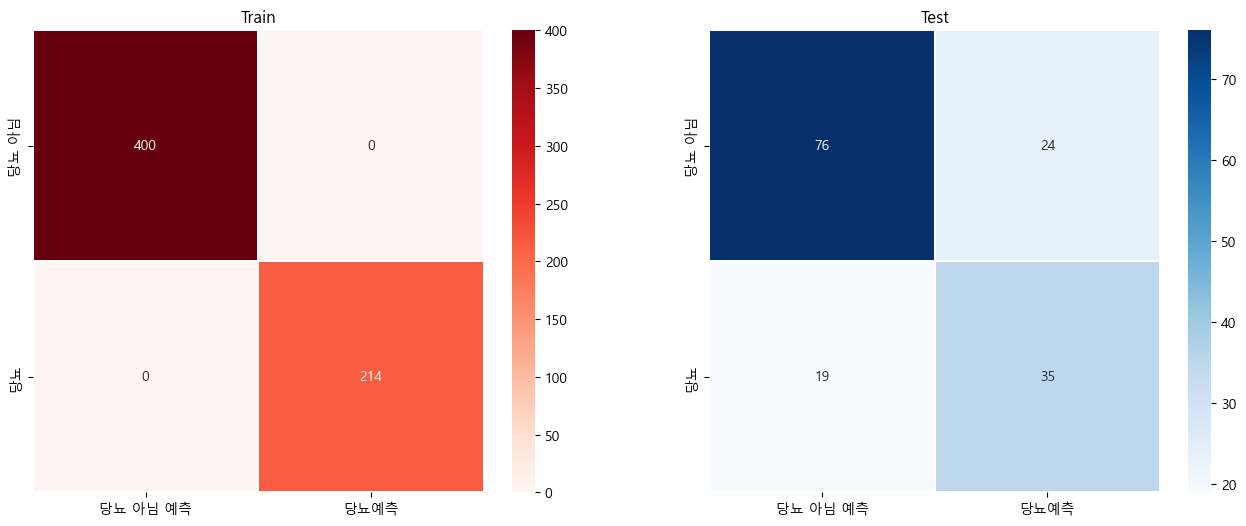

In [72]:
c_tr = confusion_matrix(y_train, pred_tr)
c_ts = confusion_matrix(y_test, pred_ts)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))


sb.heatmap(c_tr, annot=True, fmt='d', linewidths=0.3, cmap='Reds',
            xticklabels=['당뇨 아님 예측', '당뇨예측'],
            yticklabels=['당뇨 아님', '당뇨'],
            ax=ax[0])
ax[0].set_title('Train')

sb.heatmap(c_ts, annot=True, fmt='d', linewidths=0.3, cmap='Blues',
            xticklabels=['당뇨 아님 예측', '당뇨예측'],
            yticklabels=['당뇨 아님', '당뇨'],
            ax=ax[1])
ax[1].set_title('Test')
plt.show()

---

train 1,2 예측값

In [105]:
proba_tr = (model.predict(x_train_s)[:2].reshape(1,-1) > 0.5) + 0
proba_tr

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[0, 0]])